In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score

In [13]:
df = pd.read_csv('data.csv')

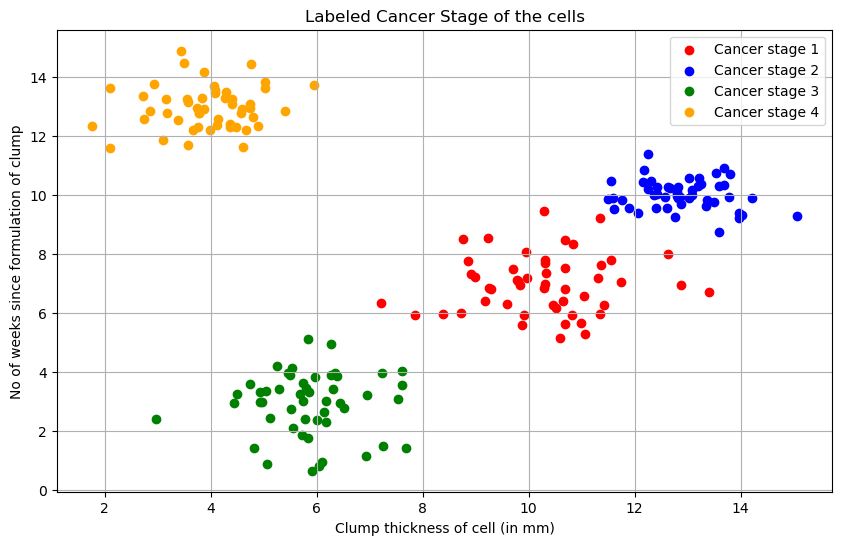

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
# show a scatter plot of ‘Clump thickness vs No of week’ and plot their class labels given in column ‘Cancer stage’ (1, 2, 3, 4) for all 200 datapoints. See the reference output image below.
col = ['red', 'blue', 'green', 'orange']
for i in range(1, 5):
    stage_data = df[df['Cancer stage'] == i]
    scatter = ax.scatter(stage_data['Clump thickness'], stage_data['No of week'], label=f'Cancer stage {i}', color=col[i-1])
ax.set_xlabel('Clump thickness of cell (in mm)')
ax.set_ylabel('No of weeks since formulation of clump')
ax.set_title('Labeled Cancer Stage of the cells')
ax.grid()
ax.legend()

In [15]:
#Now train the semi supervised model for the labeled 200 datapoints and make predictions for class label of new 2000 added datapoints and plot the scatters. Use KNN for base estimator. Use Model.fit() and model.predict() for training and prediction

labeled = df[df['Cancer stage'].notna()]
X_labeled = labeled[['Clump thickness', 'No of week']]
y_labeled = labeled['Cancer stage']

X_unlabeled = df[['Clump thickness_new', 'No of week_new']].rename(columns={'Clump thickness_new': 'Clump thickness', 'No of week_new': 'No of week'})

X_combined = pd.concat([X_labeled, X_unlabeled], ignore_index=True)
y_combined = pd.concat([y_labeled, pd.Series([-1] * len(X_unlabeled))], ignore_index=True)

knn = KNeighborsClassifier(n_neighbors=5)
self_training_model = SelfTrainingClassifier(knn)
self_training_model.fit(X_combined, y_combined)
y_pred = self_training_model.predict(X_unlabeled)

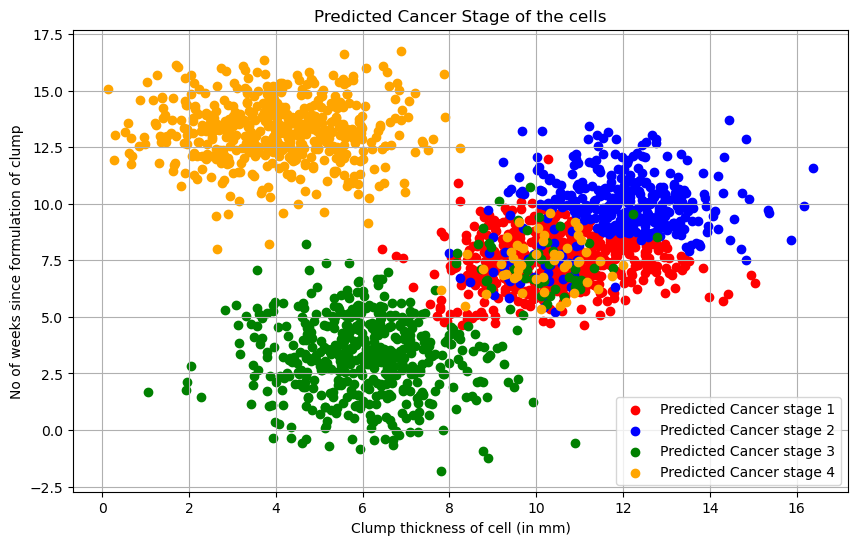

In [16]:
# Now train the semi supervised model for the labeled 200 datapoints and make predictions for class label of new 2000 added datapoints and plot the scatters. Use KNN for base estimator. Use Model.fit() and model.predict() for training and prediction


X_labeled = df[df['Cancer stage'].notna()][['Clump thickness', 'No of week']]
y_labeled = df[df['Cancer stage'].notna()]['Cancer stage']
X_unlabeled = df[df['Cancer stage'].isna()][['Clump thickness_new', 'No of week_new']]
X_unlabeled = X_unlabeled.rename(columns={'Clump thickness_new': 'Clump thickness', 'No of week_new': 'No of week'})

X_combined = pd.concat([X_labeled, X_unlabeled])
y_combined = pd.concat([y_labeled, pd.Series([-1] * len(X_unlabeled))])

knn = KNeighborsClassifier(n_neighbors=5)
self_training_model = SelfTrainingClassifier(knn)
self_training_model.fit(X_combined, y_combined)
y_pred = self_training_model.predict(X_unlabeled)   

# plot predicted data

df['y_pred'] = pd.concat([y_labeled, pd.Series(y_pred)], ignore_index=True)
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(1, 5):
    stage_data = df[df['y_pred'].astype(int) == i]
    scatter = ax.scatter(stage_data['Clump thickness_new'], stage_data['No of week_new'], label=f'Predicted Cancer stage {i}', color=col[i-1])
ax.set_xlabel("Clump thickness of cell (in mm)")
ax.set_ylabel("No of weeks since formulation of clump")
ax.set_title("Predicted Cancer Stage of the cells")
ax.grid()
ax.legend()


Accuracy Score: 0.8205
Balanced Accuracy Score: 0.8205
Classification Report:
               precision    recall  f1-score   support

           1       0.63      0.69      0.66       500
           2       0.85      0.64      0.73       500
           3       0.91      0.96      0.93       500
           4       0.90      1.00      0.95       500

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



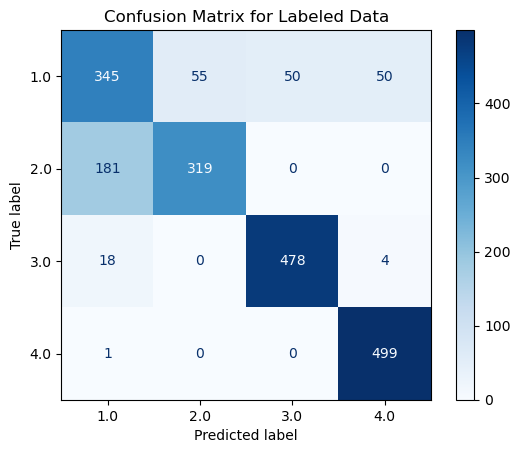

In [17]:
cm = confusion_matrix(df['True cancer stage'], df['y_pred'])
#  Compute and print accuracy score, plot classification report and the confusion matrix
print("Accuracy Score:", accuracy_score(df['True cancer stage'], df['y_pred']))
print("Balanced Accuracy Score:", balanced_accuracy_score(df['True cancer stage'], df['y_pred']))
print("Classification Report:\n", classification_report(df['True cancer stage'], df['y_pred']))
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=self_training_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Labeled Data")
plt.show()

### Provide three applications of Semi-supervised learning.
1) Image classification: Use partially labeled images to train a model that can classify new images.
2) Natural language processing: Use a small amount of labeled text data to train a model thatcan understand and generate human language.
3) Anomaly detection: Use a small amount of labeled data to train a model that can identify unusual patterns or outliers in data, such as fraud detection infinancial transactions.
### What are the three assumptions of Semi-supervised learning?
1) Continuity assumption: The data points that are close to each other in the feature space are likely to belong to the same class.
2) Cluster assumption: The data points that belong to the same class are likely to form a cluster in the feature space.
3) Manifold assumption: The data points lie on a low-dimensional manifold in the high-dimensional feature space, and the structure of this manifold can be used to learn the underlying distribution of the data.
### What is significance each of using the above three assumptions in Semi-supervised Learning?
1) Continuity assumption: This assumption allows the model to generalize from the labeled data to the unlabeled data by assuming that similar data points have similar labels.
2) Cluster assumption: This assumption allows the model to leverage the structure of the data to improve classification performance by grouping similar data points together.
3) Manifold assumption: This assumption allows the model to learn the underlying structure of the data, which can help in improving the performance of the model by capturing the intrinsic geometry of the data distribution.
### How does the Co-training method differ from the Self-training method of Semi-supervised learning? Which one usually performs better for accuracy and such performance metrics?
The Co-training method involves training two separate models on different views of the data, where each model is trained on a different subset of features. The models then iteratively label the unlabeled data for each other, allowing them to learn from each other's predictions. In contrast, the Self-training method involves training a single model on the labeled data and then using that model to label the unlabeled data, which is then added to the training set for further iterations.
### How to evaluate the performance of a semi-supervised learning method while training?
To evaluate the performance of a semi-supervised learning method while training, you can use a validation set that contains both labeled and unlabeled data. You can compute metrics such as accuracy, precision, recall, and F1-score on the validation set to assess how well the model is performing. Additionally, you can monitor the learning curve to see how the model's performance changes as it learns from more unlabeled data.